# Dog vs Cat Image Classification
This notebook demonstrates a simple binary classification model using TensorFlow and Keras.

In [1]:
!pip install tensorflow opencv-python matplotlib -q

## 1. Environment Setup and Imports
Installing and importing necessary libraries for computer vision and deep learning.

In [2]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

## 2. Dataset Loading
Loading the 'cats_vs_dogs' dataset from TensorFlow Datasets.

In [3]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

train_data = dataset['train']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.6X2MUB_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


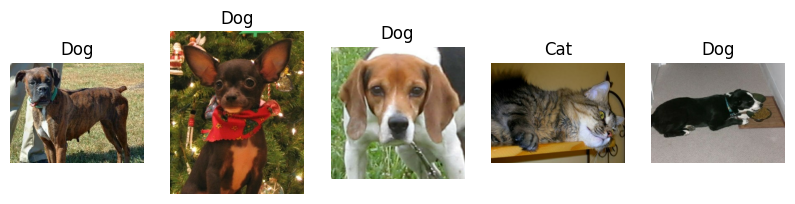

In [4]:
plt.figure(figsize=(10,5))

for i, (image, label) in enumerate(train_data.take(5)):
    plt.subplot(1,5,i+1)
    plt.imshow(image)
    plt.title("Dog" if label.numpy() == 1 else "Cat")
    plt.axis("off")

plt.show()

## 3. Data Preprocessing
Normalizing and resizing images to prepare them for the neural network.

In [5]:
IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_data = train_data.map(preprocess).batch(32).take(200)  # small subset

## 4. Model Architecture
Building a Convolutional Neural Network (CNN) for binary classification.

In [6]:
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,417 (7.05 MB)

 Trainable params: 1,848,417 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Training
Training the model on a subset of the data.

In [7]:
history = model.fit(train_data, epochs=3)

Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 387ms/step - accuracy: 0.6295 - loss: 0.6433
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 372ms/step - accuracy: 0.7533 - loss: 0.5118
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 369ms/step - accuracy: 0.8130 - loss: 0.4173


## 6. Inference and Visualization
Defining a prediction function and testing it on an image.

In [8]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (128,128))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    prediction = model.predict(img_input)[0][0]

    label = "Dog" if prediction > 0.5 else "Cat"
    return img, label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


(np.float64(-0.5), np.float64(258.5), np.float64(193.5), np.float64(-0.5))

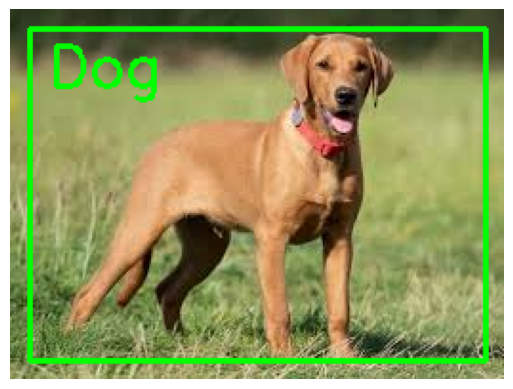

In [9]:
img, label = predict_image("image1.jpg")

# Draw a simple bounding box (whole image)
h, w, _ = img.shape
cv2.rectangle(img, (10,10), (w-10, h-10), (0,255,0), 2)

cv2.putText(img, label, (20,40),
            cv2.FONT_HERSHEY_SIMPLEX, 1,
            (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


(np.float64(-0.5), np.float64(426.5), np.float64(639.5), np.float64(-0.5))

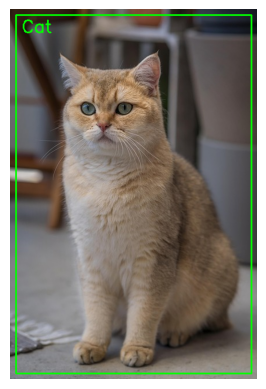

In [10]:
img, label = predict_image("image2.jpg")

# Draw a simple bounding box (whole image)
h, w, _ = img.shape
cv2.rectangle(img, (10,10), (w-10, h-10), (0,255,0), 2)

cv2.putText(img, label, (20,40),
            cv2.FONT_HERSHEY_SIMPLEX, 1,
            (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')